# Assessing Bicycle Lane Quality Using Smartphone Sensor Data

This notebook contains the complete data analysis pipeline for
classifying bicycle-lane sections as Smooth or Bumpy using
smartphone sensor data.

The analysis includes data loading, preprocessing, feature
extraction, feature selection, supervised and unsupervised
learning, model evaluation, and deployment.

## 0. Environment and Reproducibility
The Python environment and package versions are recorded below to
support reproducibility.

In [1]:
import sys

import pandas as pd
import numpy as np
import sklearn
import matplotlib
import matplotlib.pyplot as plt

print("Python version:", sys.version)
print("pandas:", pd.__version__)
print("numpy:", np.__version__)
print("scikit-learn:", sklearn.__version__)
print("matplotlib:", matplotlib.__version__)

Python version: 3.13.5 | packaged by Anaconda, Inc. | (main, Jun 12 2025, 16:37:03) [MSC v.1929 64 bit (AMD64)]
pandas: 2.2.3
numpy: 2.3.5
scikit-learn: 1.9.0
matplotlib: 3.10.0


In [2]:
#Standard library only
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

from sklearn.cluster import (
    KMeans,
    AgglomerativeClustering,
    DBSCAN
)
from sklearn.mixture import GaussianMixture

from sklearn.metrics import (
    silhouette_score,
    adjusted_rand_score
)

from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

## Data Collection Metadata

The dataset was collected using smartphone sensor recordings while cycling
on smooth and bumpy bicycle lanes.

The following metadata documents the phone used, phone placement, bicycle,
and route characteristics for each recording.

In [3]:
Collection_info = {'P1':{'Phone':'iphone 15', 'placement':'Vertical on bicycle basket'},
                   'P2':{'Phone':'iphone 13', 'placement':'Vertical on bicycle basket'},
                   'P3':{'Phone':'iphone 17 pro max', 'placement':'Vertical on bicycle basket'}}

Route_info = {'P1_smooth': 'Near Geldropsedijk bus stop','P1_bumpy': 'Eisenhowerlaan',
    'P2_smooth': '','P2_bumpy': '',
    'P3_smooth': '','P3_bumpy': ''}



In [4]:
def load_and_merge(acc_path, grav_path, gyro_path):
    """
    Load accelerometer, gravity, and gyroscope data and combine
    them using their timestamps.
    """

    acc = pd.read_csv(acc_path).rename(
        columns={'x': 'acc_x', 'y': 'acc_y', 'z': 'acc_z'}
    )

    grav = pd.read_csv(grav_path).rename(
        columns={'x': 'grav_x', 'y': 'grav_y', 'z': 'grav_z'}
    )

    gyro = pd.read_csv(gyro_path).rename(
        columns={'x': 'gyro_x', 'y': 'gyro_y', 'z': 'gyro_z'}
    )

    # Check that all recordings have the same number of observations
    if not (len(acc) == len(grav) == len(gyro)):
        raise ValueError("Sensor files have different numbers of rows.")

    # Check timestamp alignment
    if not acc['time'].equals(grav['time']):
        raise ValueError("Accelerometer and gravity timestamps are not aligned.")

    if not acc['time'].equals(gyro['time']):
        raise ValueError("Accelerometer and gyroscope timestamps are not aligned.")

    # Combine the sensor measurements
    df = acc[
        ['time', 'seconds_elapsed', 'acc_x', 'acc_y', 'acc_z']
    ].copy()

    df[['grav_x', 'grav_y', 'grav_z']] = grav[
        ['grav_x', 'grav_y', 'grav_z']
    ]

    df[['gyro_x', 'gyro_y', 'gyro_z']] = gyro[
        ['gyro_x', 'gyro_y', 'gyro_z']
    ]

    return df


In [5]:
# Define the location of each participant's recordings

recordings = {
    'P1_smooth': {
        'label': 'smooth',
        'folder': 'data_raw/Smooth/P1'
    },
    'P1_bumpy': {
        'label': 'bumpy',
        'folder': 'data_raw/Bumpy/P1'
    },
    'P2_smooth': {
        'label': 'smooth',
        'folder': 'data_raw/Smooth/P2'
    },
    'P2_bumpy': {
        'label': 'bumpy',
        'folder': 'data_raw/Bumpy/P2'
    },
    'P3_smooth': {
        'label': 'smooth',
        'folder': 'data_raw/Smooth/P3'
    },
    'P3_bumpy': {
        'label': 'bumpy',
        'folder': 'data_raw/Bumpy/P3'
    }
}

In [6]:
merge_recordings = {}

for name, recording in recordings.items():

    folder = recording['folder']

    df = load_and_merge(
        f"{folder}/Accelerometer.csv",
        f"{folder}/Gravity.csv",
        f"{folder}/Gyroscope.csv")

    merge_recordings[name] = df

    print(
        f"{name}: "
        f"{len(df)} rows, "
        f"{df['seconds_elapsed'].max():.1f} seconds"
    )

P1_smooth: 7719 rows, 77.3 seconds
P1_bumpy: 18010 rows, 180.4 seconds
P2_smooth: 12576 rows, 126.8 seconds
P2_bumpy: 19553 rows, 197.2 seconds
P3_smooth: 4763 rows, 47.8 seconds
P3_bumpy: 7583 rows, 76.2 seconds


In [7]:
def recording_quality(key, df):
    t = df['seconds_elapsed'].values
    dt = np.diff(t)

    return {
        'recording': key,
        'rows': len(df),
        'duration_s': round(t[-1] - t[0], 1),
        'effective_hz': round(
            (len(t) - 1) / (t[-1] - t[0]), 1
        ),
        'median_dt_ms': round(
            np.median(dt) * 1000, 2
        ),
        'max_gap_ms': round(
            dt.max() * 1000, 2
        ),
        'missing_values': int(
            df.isna().sum().sum()
        ),
        'duplicate_timestamps': int(
            df['time'].duplicated().sum()
        )
    }


quality = pd.DataFrame(
    [
        recording_quality(name, df)
        for name, df in merge_recordings.items()
    ]
).set_index('recording')

display(quality)

,rows,duration_s,effective_hz,median_dt_ms,max_gap_ms,missing_values,duplicate_timestamps
recording,,,,,,,
P1_smooth,7719,77.3,99.9,10.01,10.64,0,0
P1_bumpy,18010,180.3,99.9,10.01,16.27,0,0
P2_smooth,12576,126.7,99.2,10.08,10.08,0,0
P2_bumpy,19553,197.1,99.2,10.08,10.08,0,0
P3_smooth,4763,47.8,99.6,10.04,10.04,0,0
P3_bumpy,7583,76.1,99.6,10.04,10.67,0,0


In [8]:
print(
    "Total duration: %.1f min" %
    (quality['duration_s'].sum() / 60)
)

print(
    "Total samples per sensor: %d" %
    quality['rows'].sum()
)

Total duration: 11.8 min
Total samples per sensor: 70204


In [9]:
def signal_summary(df):
    # Calculate the overall acceleration magnitude
    magnitude = np.sqrt(
        df['acc_x']**2 +
        df['acc_y']**2 +
        df['acc_z']**2
    )

    return {
        'std': magnitude.std(),
        'p99': np.percentile(magnitude, 99),
        'max': magnitude.max(),
        'pct_samples_above_10': (magnitude > 10).mean() * 100
    }


rows = {}

for name, df in merge_recordings.items():
    rows[name] = signal_summary(df)


label_quality = (
    pd.DataFrame(rows)
    .T
    .round(2)
    .rename(columns={
        'pct_samples_above_10': '% samples > 10 m/s²'
    })
)

display(label_quality)

,std,p99,max,% samples > 10 m/s²
P1_smooth,0.97,4.78,10.23,0.01
P1_bumpy,3.47,16.07,55.13,5.37
P2_smooth,0.93,4.76,8.68,0.00
P2_bumpy,2.68,13.20,47.01,3.41
P3_smooth,0.76,3.83,10.52,0.04
P3_bumpy,2.67,14.24,27.80,3.77


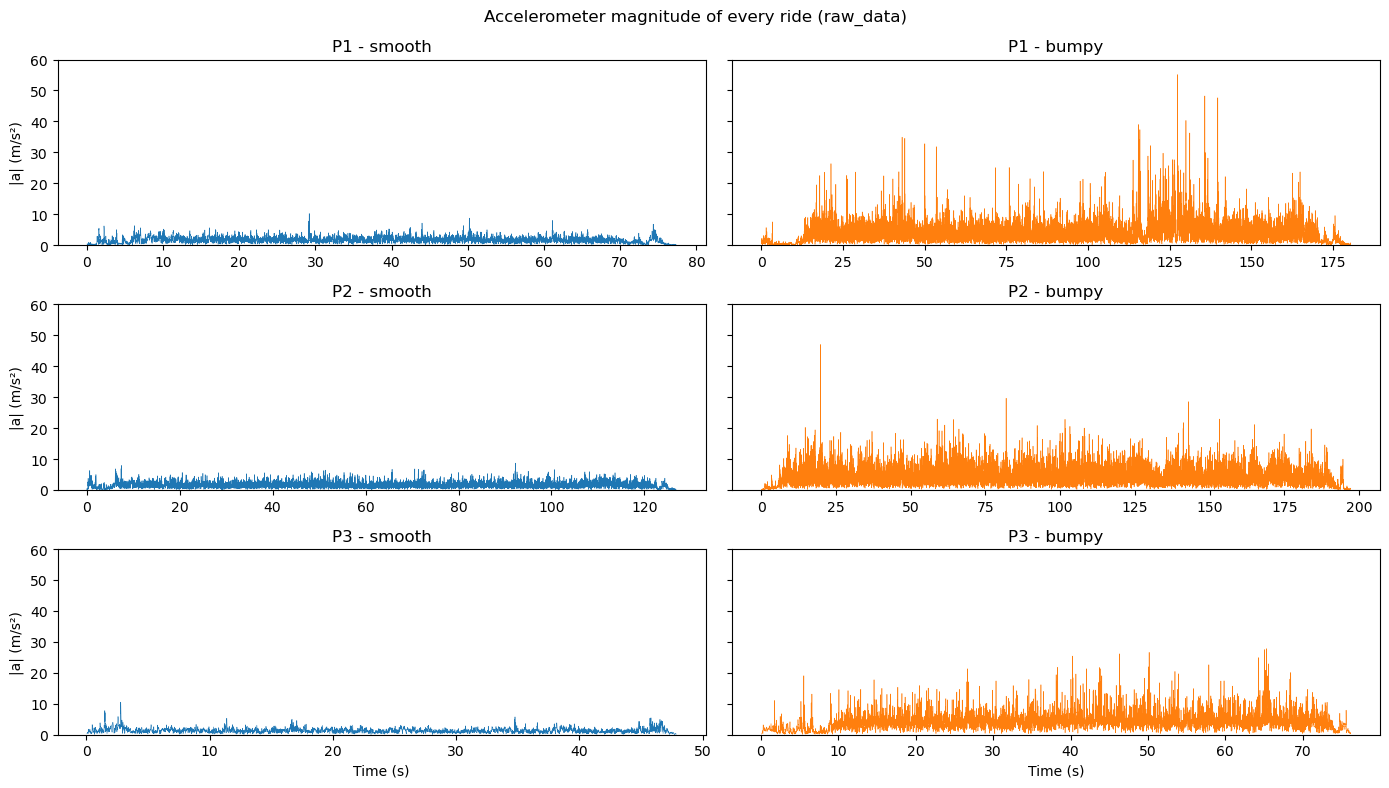

In [10]:
PIDS = ['P1', 'P2', 'P3']

fig, axes = plt.subplots(3, 2, figsize=(14, 8), sharey=True)

for i, pid in enumerate(PIDS):

    for j, cls in enumerate(['smooth', 'bumpy']):

        df = merge_recordings[f'{pid}_{cls}']

        mag = np.sqrt(
            df['acc_x']**2 +
            df['acc_y']**2 +
            df['acc_z']**2
        )

        axes[i, j].plot(
            df['seconds_elapsed'],
            mag,
            lw=0.4,
            color='tab:blue' if cls == 'smooth' else 'tab:orange'
        )

        axes[i, j].set_title(f'{pid} - {cls}')
        axes[i, j].set_ylim(0, 60)

        if j == 0:
            axes[i, j].set_ylabel('|a| (m/s²)')

for ax in axes[-1]:
    ax.set_xlabel('Time (s)')

plt.suptitle(
    'Accelerometer magnitude of every ride (raw_data)'
)

plt.tight_layout()
plt.show()

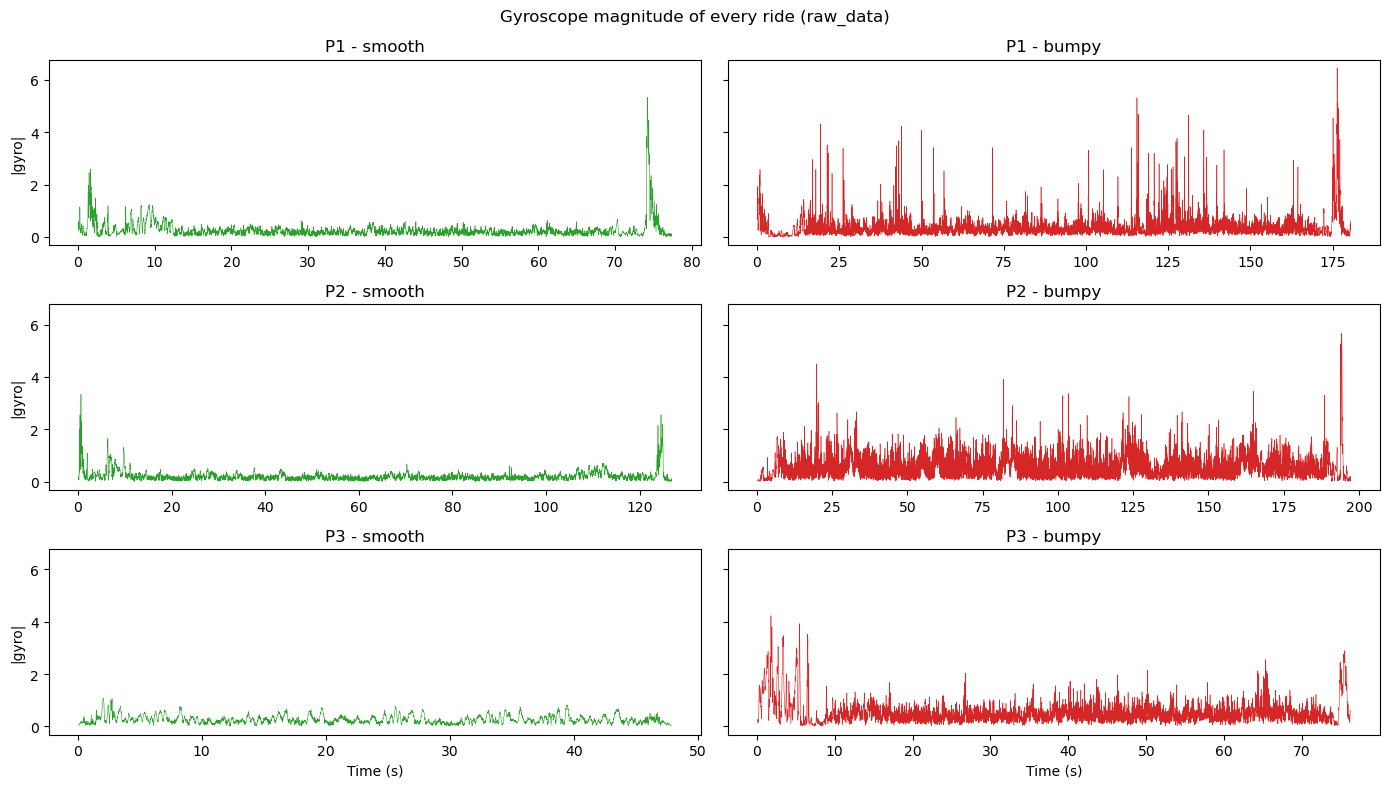

In [11]:
PIDS = ['P1', 'P2', 'P3']

fig, axes = plt.subplots(3, 2, figsize=(14, 8), sharey=True)

for i, pid in enumerate(PIDS):

    for j, cls in enumerate(['smooth', 'bumpy']):

        df = merge_recordings[f'{pid}_{cls}']

        gyro_mag = np.sqrt(
            df['gyro_x']**2 +
            df['gyro_y']**2 +
            df['gyro_z']**2
        )

        axes[i, j].plot(
            df['seconds_elapsed'],
            gyro_mag,
            lw=0.4,
            color='tab:green' if cls == 'smooth' else 'tab:red'
        )

        axes[i, j].set_title(f'{pid} - {cls}')

        if j == 0:
            axes[i, j].set_ylabel('|gyro|')

for ax in axes[-1]:
    ax.set_xlabel('Time (s)')

plt.suptitle('Gyroscope magnitude of every ride (raw_data)')
plt.tight_layout()
plt.show()

Trim Window

In [19]:
Sampling_freq = 100
steps = 1
window = 2

window_size = Sampling_freq * window
step_size = Sampling_freq * steps

def create_window(df, window_size, step_size):
    windows = []

    for start in range (0, len(df)-window_size+1, step_size):
        end = start + window_size
        windows.append(df.iloc[start:end].copy())

    print(len(windows))
    print(len(windows[0]))
    print("Rows:", len(merge_recordings['P1_smooth']))
    print("Duration:", merge_recordings['P1_smooth']['seconds_elapsed'].iloc[-1])
    print("Windows:", len(windows))
    print("Window size:", len(windows[0]))
    return windows

create_window(merge_recordings['P1_smooth'], window_size, step_size)

for name, df in merge_recordings.items():
    windows = create_window(df, window_size, step_size)
    #print(len(windows[0]))
    print(
        name,
        "| rows:", len(df),
        "| duration:", round(df['seconds_elapsed'].iloc[-1], 2),
        "| windows:", len(windows)
    )

    





76
200
Rows: 7719
Duration: 77.32330200195312
Windows: 76
Window size: 200
76
200
Rows: 7719
Duration: 77.32330200195312
Windows: 76
Window size: 200
P1_smooth | rows: 7719 | duration: 77.32 | windows: 76
179
200
Rows: 7719
Duration: 77.32330200195312
Windows: 179
Window size: 200
P1_bumpy | rows: 18010 | duration: 180.36 | windows: 179
124
200
Rows: 7719
Duration: 77.32330200195312
Windows: 124
Window size: 200
P2_smooth | rows: 12576 | duration: 126.8 | windows: 124
194
200
Rows: 7719
Duration: 77.32330200195312
Windows: 194
Window size: 200
P2_bumpy | rows: 19553 | duration: 197.15 | windows: 194
46
200
Rows: 7719
Duration: 77.32330200195312
Windows: 46
Window size: 200
P3_smooth | rows: 4763 | duration: 47.85 | windows: 46
74
200
Rows: 7719
Duration: 77.32330200195312
Windows: 74
Window size: 200
P3_bumpy | rows: 7583 | duration: 76.18 | windows: 74


Feature extraction

In [ ]:
def extract_features(window):
    #magnitude
    acc_mag = np.sqrt(window['acc_x']**2+window['acc_y']**2+window['acc_z']**2)
    grav_mag = 